In [1]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration, AutoProcessor
from datasets import load_dataset, Audio
from src.ModelWrapper import ModelWrapper
import torch
from pyaml_env import parse_config
from src.utils_contributions import compute_alti
import pandas as pd
import seaborn as sns
#from transformers import pipeline

processor = WhisperProcessor.from_pretrained("openai/whisper-small")
#processor = AutoProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small", attn_implementation="eager")
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
'''
print(model.forward.__annotations__)
print(model.config.output_attentions)
print(model.config.output_hidden_states)
print(model.config.return_dict)
print(config['models'][model.config.model_type])
print(model.config.num_attention_heads)
print(model.config.hidden_size / model.config.num_attention_heads)
print(device)
print(model.model.decoder)
'''     
# outputs = model(output_attentions=True, output_hidden_states=True)
# print(type(outputs))

"\nprint(model.forward.__annotations__)\nprint(model.config.output_attentions)\nprint(model.config.output_hidden_states)\nprint(model.config.return_dict)\nprint(config['models'][model.config.model_type])\nprint(model.config.num_attention_heads)\nprint(model.config.hidden_size / model.config.num_attention_heads)\nprint(device)\nprint(model.model.decoder)\n"

In [2]:
model_wrapped = ModelWrapper(model)

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 768)
      (layers): ModuleList(
        (0-11): 12 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (f

In [3]:
ds = load_dataset("Isma/librispeech_tiny")
ds = ds["1h"]

In [4]:
def contains_word(example, word):
    return word in example["text"].lower().split()

def transcribe(ds):
    result_list = []
    for sample in ds:
        audio = sample["audio"]
        input_features = processor(
            audio["array"],
            sampling_rate=audio["sampling_rate"],
            return_tensors="pt"
        ).input_features.to(model.device)

        generated_ids = model.generate(input_features, language="en", task="transcribe")
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        result_list.append(text)
    return result_list

In [5]:
pair_homophones = ds.filter(
    lambda ex: contains_word(ex, "pair") or contains_word(ex, "pear")
)
print(len(pair_homophones))

1


In [6]:
transcriptions = transcribe(pair_homophones)

for i, t in enumerate(transcriptions):
    print(f"Sample {i}: {t}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Sample 0:  Then he made all his servants go to, his cooks and his gardeners and his barber and Prince Bumpo's tutor, even the queen, who was tired from dancing in a pair of tight shoes.


In [7]:
target = " pair"
foil = " pear"

CORRECT_ID = processor.tokenizer(target, add_special_tokens=False).input_ids[0]
FOIL_ID = processor.tokenizer(foil, add_special_tokens=False).input_ids[0]

token = [CORRECT_ID, FOIL_ID]
input_features = None
for sample in pair_homophones:
    audio = sample["audio"]
    input_features = processor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt"
    ).input_features.to(model.device)

generated_ids = model.generate(input_features, language="en", task="transcribe")
decoded_ids = generated_ids[0]
decoded_text = processor.decode(decoded_ids, skip_special_tokens=True)
decoded_tokens = processor.tokenizer(
    decoded_text,
    add_special_tokens=False
).input_ids

target_pos = decoded_tokens.index(CORRECT_ID)

# decoder prefix
decoder_input_ids = torch.tensor(
    decoded_tokens[:target_pos],
    device=model.device
).unsqueeze(0)

outputs = model(
    input_features=input_features,
    decoder_input_ids=decoder_input_ids,
    output_hidden_states=True,
    output_attentions=True,
    return_dict=True,
)

prediction_scores, hidden_states, attentions, encoder_hidden_states, cross_attentions = (
    model_wrapped({
        "input_features": input_features,
        "decoder_input_ids": decoder_input_ids
    })
)

# prediction_scores contains logits
step_logits = prediction_scores[0, -1]
logit_diff = step_logits[CORRECT_ID] - step_logits[FOIL_ID]
print("logit diff:", logit_diff.item())

logit_trans_vect_dict, logits_modules, layer_alti_data = (
    model_wrapped.get_logit_contributions(
        hidden_states=hidden_states,
        attentions=attentions,
        token=token,
        output_pos=-1,
        encoder_hidden_states=encoder_hidden_states,
        cross_attentions=cross_attentions
    )
)

'''contrastive_contributions = (
    layer_alti_data[CORRECT_ID] - layer_alti_data[FOIL_ID]
)

print(contrastive_contributions)'''

logit diff: 7.408452987670898
model.decoder.layers
model.decoder.layers
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_heads:  torch.Size([1, 37, 768])
unembed:  torch.Size([2, 768])
model.decoder.layers
l_lin_enc_x_i_he

'contrastive_contributions = (\n    layer_alti_data[CORRECT_ID] - layer_alti_data[FOIL_ID]\n)\n\nprint(contrastive_contributions)'

In [8]:
contributions_mix_alti = compute_alti(layer_alti_data)

How much did encoder cross-attention contribute to the logit difference between two tokens, aggregated over encoder positions

<Axes: >

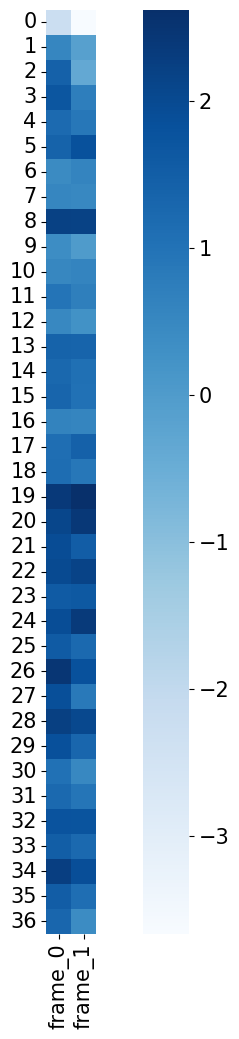

In [ ]:

# sum over heads and vocab dimension to get frame-level contribution
frame_contributions = logit_trans_vect_dict['lin_x_j_h'].sum(axis=1).sum(axis=-1)  # [layers, tgt_len, src_len]

layer_idx = -1
df = pd.DataFrame(frame_contributions[layer_idx].cpu().numpy(), columns=[f"frame_{i}" for i in range(frame_contributions.shape[-1])])
sns.heatmap(df, cmap="Blues", square=True)


In [ ]:
# sum over heads and vocab dimension to get frame-level contribution
frame_contributions = logit_trans_vect_dict['lin_x_j_h'].sum(axis=1).sum(axis=-1)  # [layers, tgt_len, src_len]

layer_idx = -1
df = pd.DataFrame(frame_contributions[layer_idx].cpu().numpy(), columns=[f"frame_{i}" for i in range(frame_contributions.shape[-1])])
sns.heatmap(df, cmap="Blues", square=True)
